In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load synthetic dataset
df = pd.read_csv('../data/raw_data/house_prices_raw.csv')

# Inspect structure
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
display(df.describe())

Dataset shape: (5000, 9)

First 5 rows:


,property_id,location,area_sqft,bedrooms,bathrooms,age_years,price_lakhs,parking_spaces,amenities_count
0,1,Hyderabad,875.862116,1,4,2.426673,483.074029,1,9
1,2,Chennai,1450.066742,5,2,37.214047,30.858347,1,5
2,3,Bangalore,3886.107519,3,4,37.304673,303.181110,3,8
3,4,Chennai,730.822320,5,4,33.536287,392.656382,2,2
4,5,Chennai,2716.409213,4,1,32.181689,398.190230,0,7



Data types:
property_id          int64
location            object
area_sqft          float64
bedrooms             int64
bathrooms            int64
age_years          float64
price_lakhs        float64
parking_spaces       int64
amenities_count      int64
dtype: object

Missing values:
property_id        0
location           0
area_sqft          0
bedrooms           0
bathrooms          0
age_years          0
price_lakhs        0
parking_spaces     0
amenities_count    0
dtype: int64

Basic statistics:


,property_id,area_sqft,bedrooms,bathrooms,age_years,price_lakhs,parking_spaces,amenities_count
count,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2708.539249,3.00620,2.49880,25.393258,264.357617,1.482800,4.598800
std,1443.520003,1289.036959,1.41752,1.11492,14.362135,138.423830,1.106503,2.863543
min,1.000000,500.138235,1.00000,1.00000,0.012623,20.023099,0.000000,0.000000
25%,1250.750000,1595.574218,2.00000,2.00000,13.246248,144.620242,1.000000,2.000000
50%,2500.500000,2683.675280,3.00000,2.00000,25.545415,267.200060,1.000000,5.000000
75%,3750.250000,3800.058772,4.00000,3.00000,37.582095,382.173081,2.000000,7.000000
max,5000.000000,4997.573065,5.00000,4.00000,49.996241,499.952469,3.000000,9.000000


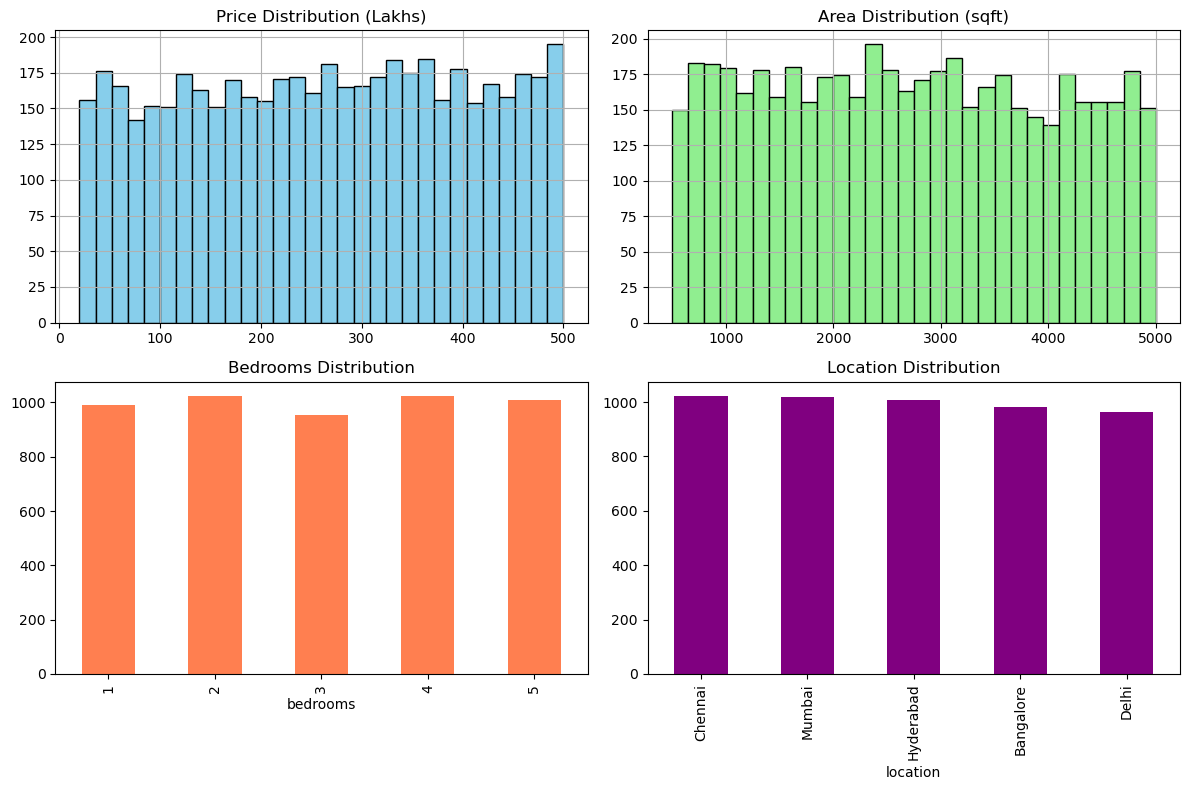

In [3]:
# Create visual distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Price distribution
df['price_lakhs'].hist(ax=axes[0, 0], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution (Lakhs)')

# Area distribution
df['area_sqft'].hist(ax=axes[0, 1], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Area Distribution (sqft)')

# Bedrooms count
df['bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Bedrooms Distribution')

# Location count
df['location'].value_counts().plot(kind='bar', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Location Distribution')

plt.tight_layout()
plt.savefig('../data/processed_data/01_distributions.png')
plt.show()

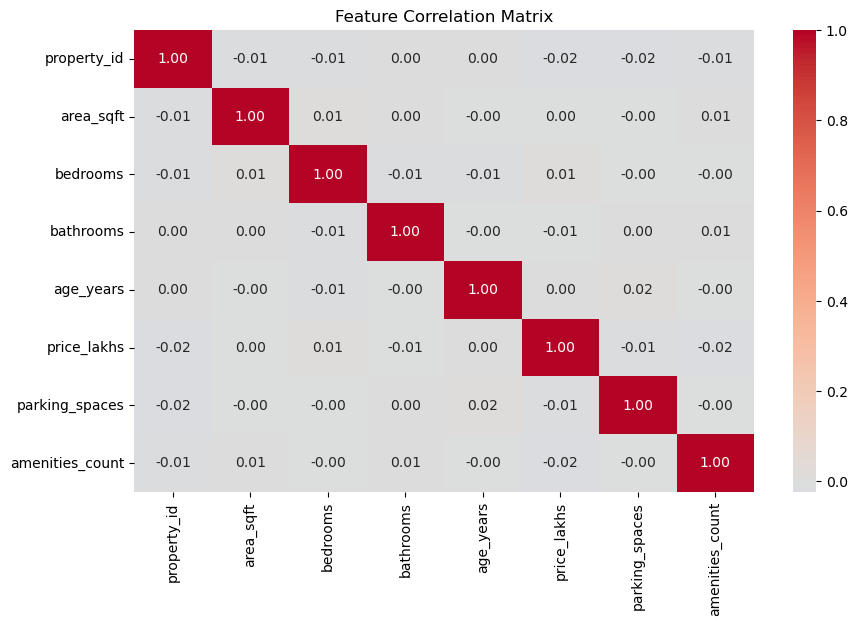

Correlation with Price (Lakhs):
price_lakhs        1.000000
bedrooms           0.010873
age_years          0.004259
area_sqft          0.000435
bathrooms         -0.006120
parking_spaces    -0.009353
amenities_count   -0.019696
property_id       -0.022768
Name: price_lakhs, dtype: float64


In [4]:
# Correlation matrix
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.savefig('../data/processed_data/02_correlation.png')
plt.show()

print("Correlation with Price (Lakhs):")
print(correlation_matrix['price_lakhs'].sort_values(ascending=False))

In [5]:
# Detect statistical outliers using IQR
for col in ['price_lakhs', 'area_sqft', 'bedrooms']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

price_lakhs: 0 outliers detected
area_sqft: 0 outliers detected
bedrooms: 0 outliers detected


In [6]:
# Price-per-sqft Analysis (Quick Win)
df['price_per_sqft'] = df['price_lakhs'] * 100000 / df['area_sqft']

print("Price per sqft statistics:")
display(df['price_per_sqft'].describe())

Price per sqft statistics:


count     5000.000000
mean     13637.604531
std      12898.514834
min        430.716393
25%       5275.439522
50%       9921.962140
75%      16898.782133
max      97598.589794
Name: price_per_sqft, dtype: float64

In [7]:
# Average price and metrics by location
location_analysis = df.groupby('location').agg({
    'price_lakhs': ['mean', 'min', 'max'],
    'area_sqft': 'mean',
    'bedrooms': 'mean'
}).round(2)

print("Location-wise Analysis:")
display(location_analysis)

Location-wise Analysis:


price_lakhs                area_sqft bedrooms
                 mean    min     max      mean     mean
location                                               
Bangalore      254.50  20.79  499.42   2759.68     2.99
Chennai        269.82  20.69  499.65   2643.96     3.00
Delhi          264.51  20.15  499.74   2702.83     3.06
Hyderabad      266.94  20.24  499.84   2708.20     3.01
Mumbai         265.67  20.02  499.95   2729.84     2.97